In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs_pure
import loglike_pure
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 12/12     # Total time



print(f"Using dt = {dt} seconds, T = {T} years")



print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs_pure.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_pure.LogLikePure(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")


Using dt = 10 seconds, T = 1.0 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 14.0812757390131
Setting up log_density and prior functions...


In [2]:

def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        try:
            loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike
        print(loglike)

    return log_likes

In [3]:
# from previous resume run
best_fit = [6.00020993, 1.00007174, 0.70045016, 8.99741125, 0.39993384]
log_density(np.array(best_fit).reshape(1,-1))

13.8936069162937


array([13.89360692])

In [4]:
from scipy.optimize import minimize

def neg_logden(x):
    val = log_density(np.array([x]))[0]
    return -val if np.isfinite(val) else 1e10

result = minimize(neg_logden, x0=best_fit, method='Nelder-Mead',
                  options={'xatol':1e-6, 'fatol':1e-6, 'maxiter':10000, 
                           'adaptive':True, 'disp':True})

best_fit_new = result.x
print('peak:', best_fit_new)
print('logden:', -result.fun)

13.8936069162937
-0.021570706050113974
0.0021886886348326836
0.005841493256700573
-1.3973464105073035e-05
6.783456871315327e-08
-8.904708194532931e-05
-4.9970503685090914e-05
-0.029137236845022188
-0.00023704313528525765
-0.0012597686437172042
0.002573377923632726
4.5078977698518964e-05
-1.0026506853529469e-06
0.0003079482324520672
-0.002570384415315924
6.675980345715171e-06
0.0005222779628929817
0.00035184946148513185
-0.00010905748439777091
-8.565208080115314e-06
0.0029270064426338144
-0.00021661553178066258
-0.0011068266205434623
-0.0008804191567963799
8.196041227515775e-06
1.1467954267311823e-05
0.0017538556441408927
-0.0008665983120196845
0.0005356029341964123
-1.9557150329124845e-06
1.3888397242839307e-05
-2.4547667457945522e-05
0.004388192542664581
-2.920605739922291e-05
-3.506988340263669e-05
0.007211203240787091
0.0033854380725340445
-0.0051121101078291774
1.6982639486410678e-05
-4.1234069574859246e-05
0.0012207169238197808
0.0023163442526064892
-1.2377284402377376e-05
1.91844

# connection

In [14]:
proc1_maxld_pt = result.x.copy().reshape(1,-1)
proc1_maxld_pt

array([[6.00074373, 1.00021502, 0.70162414, 8.9906778 , 0.39978561]])

In [15]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [16]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


13.898832537468012
13.900229527919574
13.90125589056461
13.901953463922757
13.90236718171958
13.90253532118723
13.902496558117639
13.902288846985396
13.901946768681263
13.901501621047386
13.900982811007884
13.900422779320445
13.899846976058711
13.899280682022978
13.898745168910406
13.898265465451555
13.897859244427924
13.897544855529928
13.897335801215984
13.897250248332215
13.89729398013015
13.89748097909321
13.897814272621487
13.898305981504397
13.898952797819067
13.899760534924248
13.900723861738857
13.901843163597405
13.903109871653747
13.904520511535948
13.906061748435665
13.907725313637632
13.909495490892777
13.91135873855803
13.91329694497791
13.915294047010146
13.917325039419273
13.919369750494644
13.921405348229342
13.923404045515763
13.92533996001556
13.927184031203874
13.928906132484524
13.930473212925412
13.931852766998038
13.933011229141668
13.933910923673748
13.934512791084538
13.934776241533804
13.934662556800951


In [17]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


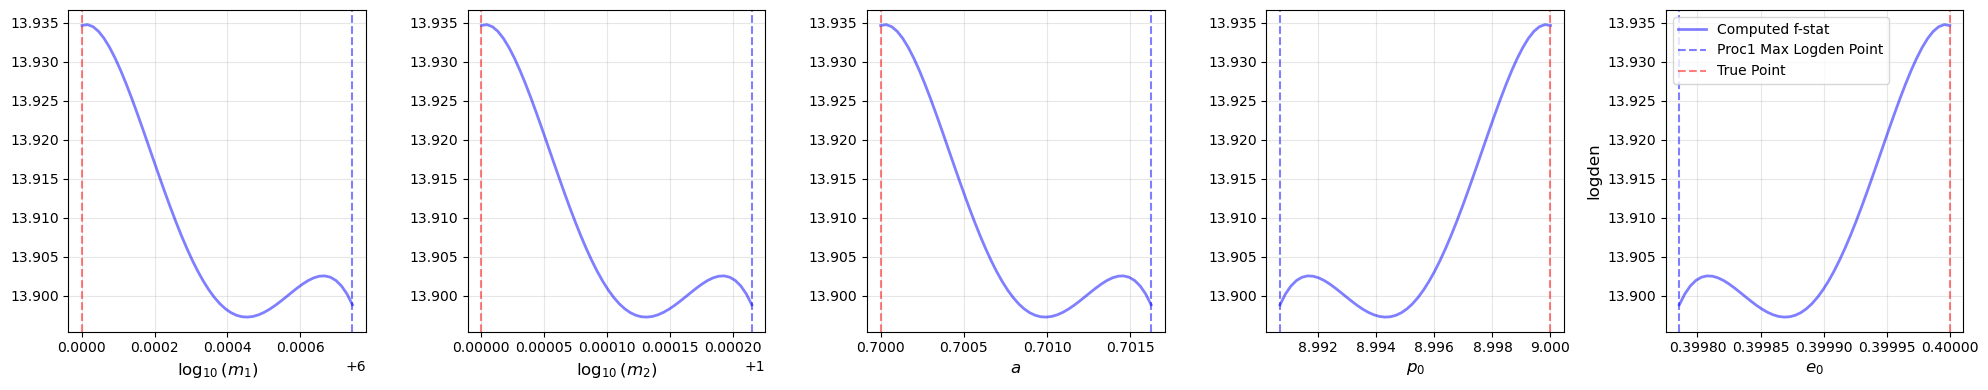

In [18]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


# whatever

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs_pure
import loglike 
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 3/12     # Total time


# -----------------------------
# PARIS global context (picklable functions require module scope)
# -----------------------------
_PARIS_EARLY_STOP_HIT = False

# Fisher-parallelotope affine prior (primary for this script)
_PARIS_AFFINE_CENTER = None       # type: Optional[np.ndarray]
_PARIS_AFFINE_Q = None            # type: Optional[np.ndarray]
_PARIS_AFFINE_B = None            # type: Optional[np.ndarray]
# _PARIS_DIM = None                 # type: Optional[int]


print(f"Using dt = {dt} seconds, T = {T} years")



print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs_pure.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike.LogLike(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")
# make this from data_snr
# _TARGET_LOGLIKE = 5.9
_TARGET_LOGLIKE = data_snr
# REVERSE TEMP for annealing
# supposed to be 1/temp if we're going with the right nomenclature 
# so supposed to be reversetemp
temp = 1

def log_density(params):
    global _PARIS_EARLY_STOP_HIT
    params = np.asarray(params)

    def eval_one(x):
        global _PARIS_EARLY_STOP_HIT
        if _PARIS_EARLY_STOP_HIT:
            return float('-inf')
        try:
            logm1, logm2, a, p0, e0 = x
            m1 = 10**logm1
            m2 = 10**logm2

            fstat = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))            
        except Exception:
            return float('-inf')
        
        if fstat >= _TARGET_LOGLIKE:
            _PARIS_EARLY_STOP_HIT = True
            try:
                print(f"[EARLY-STOP] SNR {fstat:.6f} >= {_TARGET_LOGLIKE}; future calls => -inf")
            except Exception:
                pass

        return fstat
        
    if params.ndim == 1:
        return eval_one(params)
    out = np.zeros(params.shape[0], dtype=float)
    for i in range(params.shape[0]):
        out[i] = eval_one(params[i])
    return out

In [ ]:
# from previous resume run
best_fit = [5.99924515, 1.00389791, 0.69519314, 9.02648957, 0.39784083]
log_density(best_fit)

In [ ]:
inv_cov = np.array([[ 1.62413275e+006, -1.28443452e+006,  5.67130720e+005,
                    9.57067547e+005, -9.67768736e+005],
                    [-1.28443452e+006,  1.72045648e+006, -7.15930848e+005,
                    -1.02209029e+006,  1.46765877e+006],
                    [ 5.67130720e+005, -7.15930848e+005,  4.37737159e+005,
                    5.42371762e+005, -6.08570395e+005],
                    [ 9.57067547e+005, -1.02209029e+006,  5.42371762e+005,
                    7.47638444e+005, -8.38325090e+005],
                    [-9.67768736e+005,  1.46765877e+006, -6.08570395e+005,
                    -8.38325090e+005,  1.27861238e+006]])

# Differential evolution

In [ ]:
best_fit_arr = np.array(best_fit)
n_sigma = 1
half_widths = n_sigma * np.sqrt(np.diag(np.linalg.inv(inv_cov))) 
bounds_wide = [(best_fit_arr[i] - half_widths[i], 
           best_fit_arr[i] + half_widths[i]) for i in range(5)]


In [ ]:
# testing bounds
bounds = [
    (5.9990, 6.0001),   # logm1 
    (0.999,  1.004),    # logm2
    (0.695,  0.701),    # a
    (8.999,  9.025),    # p0
    (0.397,  0.401),    # e0
]

In [ ]:
def neg_logden(x):
    val = log_density(np.array([x]))[0]
    return -val if np.isfinite(val) else 1e10

In [ ]:
from scipy.optimize import differential_evolution

_PARIS_EARLY_STOP_HIT = False

result_de = differential_evolution(
    neg_logden, bounds=bounds,
    maxiter=1000, tol=1e-6,
    seed=42, disp=True,
    popsize=10, mutation=(0.5, 1.0), recombination=0.7
)
print('logden:', -result_de.fun)
print('peak:', result_de.x)

# Nelder Mead

In [ ]:
from scipy.optimize import minimize

def neg_logden(x):
    val = log_density(np.array([x]))[0]
    return -val if np.isfinite(val) else 1e10

result = minimize(neg_logden, x0=best_fit, method='Nelder-Mead',
                  options={'xatol':1e-6, 'fatol':1e-6, 'maxiter':10000, 
                           'adaptive':True, 'disp':True})

best_fit_new = result.x
print('peak:', best_fit_new)
print('logden:', -result.fun)

# connection plot

In [ ]:
# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
import loglike 
loglike_nont = loglike.LogLike(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_nont.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)

In [ ]:
groups = [
    [(2,-2,-1),(2,-1,-1),  (2,0,-1), (2,1,-1), (2,2,-1)],#0
    [(2,-2,0),(2,-1,0),  (2,0,0), (2,1,0), (2,2,0)],#1
    [(2,-2,1),(2,-1,1),  (2,0,1), (2,1,1), (2,2,1)],#2
    [(2,-2,2),(2,-1,2),  (2,0,2), (2,1,2), (2,2,2)],#3
    [(2,-2,3),(2,-1,3),  (2,0,3), (2,1,3), (2,2,3)],#4
    [(2,-2,4),(2,-1,4),  (2,0,4), (2,1,4), (2,2,4)],#5
    [(2,-2,5),(2,-1,5),  (2,0,5), (2,1,5), (2,2,5)],#6
]

In [ ]:
maxldpt = np.array([5.99925947, 1.00391562, 0.69521331, 9.02655267, 0.39783926])

In [ ]:
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 100
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = maxldpt[:, np.newaxis] + t_values * (true_pt - maxldpt)[:, np.newaxis]


In [ ]:
def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        log_likes[i] = loglike 

    return log_likes

In [ ]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [ ]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()
logden_theory_proc1

In [ ]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(maxldpt[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Opt Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [ ]:
from scipy.optimize import differential_evolution

_PARIS_EARLY_STOP_HIT = False

bounds = [
    (5.9990, 6.0000),   # logm1 (+5.999 offset)
    (1.000,  1.004),    # logm2
    (0.695,  0.700),    # a
    (9.000,  9.025),    # p0
    (0.397,  0.400),    # e0
]

result_de = differential_evolution(
    neg_logden, bounds=bounds,
    maxiter=1000, tol=1e-6,
    seed=42, disp=True,
    popsize=10, mutation=(0.5, 1.0), recombination=0.7
)
print('logden:', -result_de.fun)
print('peak:', result_de.x)